In [19]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import torchvision.datasets as datasets

In [ ]:
mnist_train = datasets.MNIST(root="./data", train=True, download=True)
mnist_test = datasets.MNIST(root="./data", train=False, download=True)

X_train = mnist_train.data.float() / 255.0 # normalize between 0 and 1
y_train = mnist_train.targets.long()
X_test = mnist_test.data.float() / 255.0
y_test = mnist_test.targets.long()

X = torch.cat((X_train, X_test), dim=0)
y = torch.cat((y_train, y_test), dim=0)

In this notebook we are checking how the FNN behaves when we permutate or roll the data

Text(0.5, 1.0, 'Label: 5')

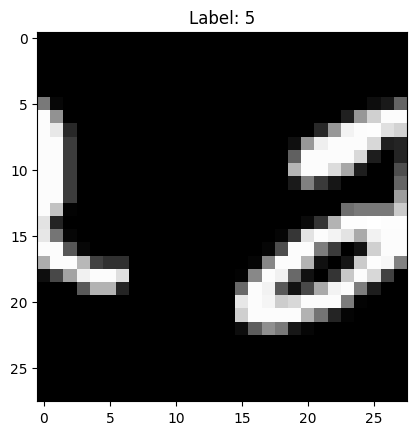

In [39]:
# Option 1) scramble the data but with the same pattern
permutation_pattern = np.random.permutation(X.shape[1])
#X = X[:, permutation_pattern, :]

# Option 2) shift the images using torch.roll
X = torch.roll(X, shifts=5, dims=2)

# plot an example
plt.imshow(X[5].reshape(28, 28), cmap='gray')
plt.title(f"Label: {y[0].item()}")

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=17, stratify=y)

In [41]:
# Convert into pytorch tensors
train_ds = TensorDataset(X_train, y_train)
test_ds = TensorDataset(X_test, y_test)

batch_size = 32
train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True)
test_dl = DataLoader(test_ds, batch_size=test_ds.tensors[0].shape[0], shuffle=False)

In [42]:
class MNIST_FNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28*28, 64) 
        self.fc2 = nn.Linear(64, 32) 
        self.fc3 = nn.Linear(32, 32)  
        self.fc4 = nn.Linear(32, 10)    

    def forward(self, x):
        x = torch.flatten(x, start_dim=1) # flatten the image, keep the batch dimension
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = self.fc4(x)
        return x

def train_one_epoch(model, train_dl, optimizer, loss_fn):
    model.train()
    batch_acc = []
    batch_loss = []
    for X_batch, y_batch in train_dl:
        output = model(X_batch)
        loss = loss_fn(output, y_batch)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        batch_acc_item = (output.argmax(dim=1) == y_batch).float().mean().item()
        batch_acc.append(batch_acc_item)
        batch_loss.append(loss.item())
        
    return np.mean(batch_acc), np.mean(batch_loss)

def train_model(model, train_dl, test_dl, optimizer, loss_fn, epochs):
    
    train_acc = np.zeros(epochs)
    test_acc = np.zeros(epochs)
    losses = np.zeros(epochs)
    
    for epoch in range(epochs):
        train_acc[epoch], losses[epoch] = train_one_epoch(model, train_dl, optimizer, loss_fn)
        
        model.eval()
        with torch.no_grad():
            for X_batch, y_batch in test_dl:
                output = model(X_batch)
                test_acc[epoch] = (output.argmax(dim=1) == y_batch).float().mean().item()
                
    return train_acc, test_acc, losses

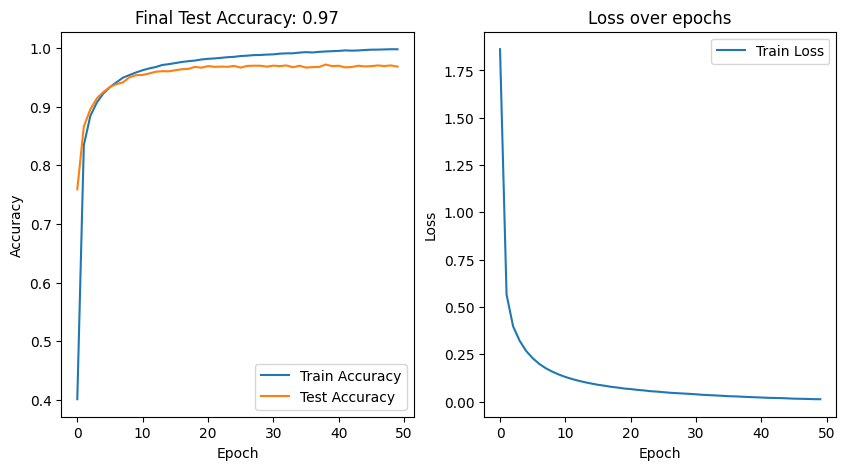

In [ ]:
# Experiment
learning_rate = 0.01
epochs = 50

# IMPORTANT: the loss fun can be reused for multiple models, it doesnt store any state,
# but the optimizer needs to be redefined for each model since it stores the state of the parameters
loss_fn = nn.CrossEntropyLoss() # CrossEntropyLoss combines nn.LogSoftmax() and nn.NLLLoss()

model = MNIST_FNN()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)  
train_acc, test_acc, losses = train_model(model, train_dl, test_dl, optimizer, loss_fn, epochs) 

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].plot(train_acc, label="Train Accuracy")
ax[0].plot(test_acc, label="Test Accuracy")
ax[0].set_title(f"Final Test Accuracy: {test_acc[-1]:.2f}")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Accuracy")
ax[0].legend()

ax[1].plot(losses, label="Train Loss")
ax[1].set_title("Loss over epochs")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Loss")
ax[1].legend()
plt.show()

# either we scramble or we shift the images, the performance remains the same
# as long as the patterns are the same in the train and test sets, the model can 
# learn to recognize them, even if they are not in the original order.